
# Temas Avanzados de Regresión
### Actividad Práctica: No-linealidad, Heteroscedasticidad y Outliers



In [ ]:
!pip install statsmodels

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn import metrics

import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

%matplotlib inline

In [ ]:
# Datos Real Estate
df = pd.read_csv('Realestate.csv')

# Renombrar columnas
df.columns = ['No', 'Fecha_Transaccion', 'Antiguedad', 'Distancia_MRT',
              'Tiendas_Conveniencia', 'Latitud', 'Longitud', 'Precio']

print("Datos cargados exitosamente")
print(f"Forma del dataset: {df.shape}")
df.head()

Datos cargados exitosamente
Forma del dataset: (414, 8)


,No,Fecha_Transaccion,Antiguedad,Distancia_MRT,Tiendas_Conveniencia,Latitud,Longitud,Precio
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
# Análisis exploratorio inicial
print("=== ESTADÍSTICAS DESCRIPTIVAS ===\n")
print(df.describe().round(2))

=== ESTADÍSTICAS DESCRIPTIVAS ===

           No  Fecha_Transaccion  Antiguedad  Distancia_MRT  \
count  414.00             414.00      414.00         414.00   
mean   207.50            2013.15       17.71        1083.89   
std    119.66               0.28       11.39        1262.11   
min      1.00            2012.67        0.00          23.38   
25%    104.25            2012.92        9.02         289.32   
50%    207.50            2013.17       16.10         492.23   
75%    310.75            2013.42       28.15        1454.28   
max    414.00            2013.58       43.80        6488.02   

       Tiendas_Conveniencia  Latitud  Longitud  Precio  
count                414.00   414.00    414.00  414.00  
mean                   4.09    24.97    121.53   37.98  
std                    2.95     0.01      0.02   13.61  
min                    0.00    24.93    121.47    7.60  
25%                    1.00    24.96    121.53   27.70  
50%                    4.00    24.97    121.54   38.45 

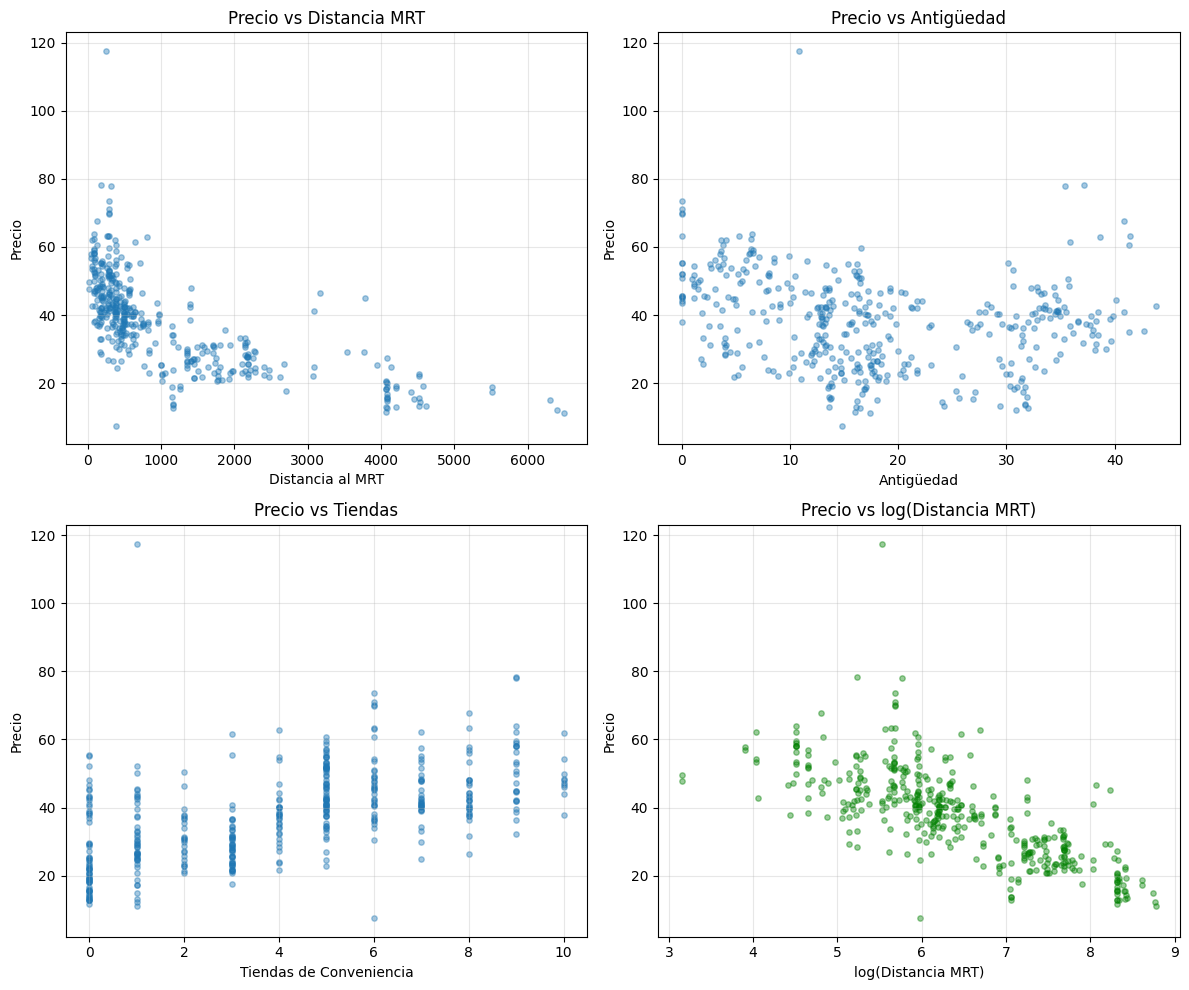

In [ ]:
# Visualización de relaciones no-lineales
# Nota como cambia log(Distancia MRT) y sin la transformación
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Precio vs Distancia MRT
axes[0, 0].scatter(df['Distancia_MRT'], df['Precio'], alpha=0.4, s=15)
axes[0, 0].set_xlabel('Distancia al MRT')
axes[0, 0].set_ylabel('Precio')
axes[0, 0].set_title('Precio vs Distancia MRT')
axes[0, 0].grid(True, alpha=0.3)

# Precio vs Antigüedad
axes[0, 1].scatter(df['Antiguedad'], df['Precio'], alpha=0.4, s=15)
axes[0, 1].set_xlabel('Antigüedad')
axes[0, 1].set_ylabel('Precio')
axes[0, 1].set_title('Precio vs Antigüedad')
axes[0, 1].grid(True, alpha=0.3)

# Precio vs Tiendas
axes[1, 0].scatter(df['Tiendas_Conveniencia'], df['Precio'], alpha=0.4, s=15)
axes[1, 0].set_xlabel('Tiendas de Conveniencia')
axes[1, 0].set_ylabel('Precio')
axes[1, 0].set_title('Precio vs Tiendas')
axes[1, 0].grid(True, alpha=0.3)

# Precio vs log(Distancia MRT)
axes[1, 1].scatter(np.log(df['Distancia_MRT']), df['Precio'], alpha=0.4, s=15, color='green')
#axes[1, 1].scatter(df['Distancia_MRT'], df['Precio'], alpha=0.4, s=15, color='green')
#axes[1, 1].set_xlabel('Distancia MRT')
axes[1, 1].set_xlabel('log(Distancia MRT)')
axes[1, 1].set_ylabel('Precio')
axes[1, 1].set_title('Precio vs log(Distancia MRT)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

INTERPRETACIÓN DE CADA GRÁFICO
  -PRECIO vs DISTANCIA: no lineal y varianza desigual. el precio cae muy rápido en los primeros mil metros y luego se aplana.
  - PRECIO vs log DISTANCIA: la transformación funciona, relación aproximadamente lineal y decreciente, la disperción es relativamente pareja. Efectos proporsionales, no absolutos como lo debe modelar un logaritmo.
  - PRECIO vs ANTIGüEDAD: no hay patrón lieela claro, una ligera forma U.
  - PRECIO vs TIENDAS:  El precio sube con el número de tiendas  y mucha disperción en cada nivel. No hay evidencia suficineta para justificar una transformación.

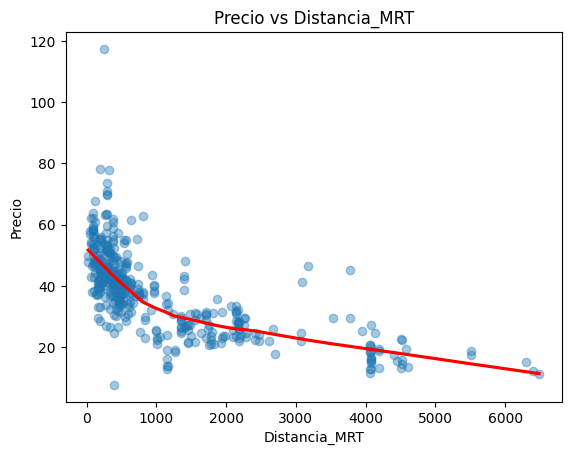

Pearson: -0.674
Spearman: -0.776
R2: 0.454


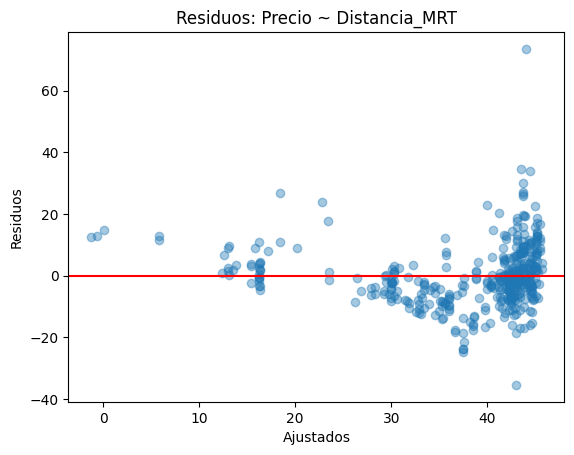

p-valor Antigüedad²: 0.0


In [ ]:

import statsmodels.formula.api as smf

df["log_dist"] = np.log(df["Distancia_MRT"])

# ---- Elige la versión: SIN log (default) o CON log ----
x = "Distancia_MRT"
# x = "log_dist"

# Curva LOWESS: si se separa de la recta, hay no linealidad
sns.regplot(data=df, x=x, y="Precio", lowess=True,
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.title(f"Precio vs {x}")
plt.show()

# Correlación y R² de la regresión simple
print("Pearson:", round(df[x].corr(df["Precio"]), 3))
print("Spearman:", round(df[x].corr(df["Precio"], method="spearman"), 3))
m = smf.ols(f"Precio ~ {x}", df).fit()
print("R2:", round(m.rsquared, 3))

# Residuos vs ajustados
plt.scatter(m.fittedvalues, m.resid, alpha=0.4)
plt.axhline(0, color="red")
plt.title(f"Residuos: Precio ~ {x}")
plt.xlabel("Ajustados"); plt.ylabel("Residuos")
plt.show()

# Prueba formal de no linealidad en Antigüedad (¿aporta el término cuadrático?)
mq = smf.ols("Precio ~ Antiguedad + I(Antiguedad**2)", df).fit()
print("p-valor Antigüedad²:", round(mq.pvalues["I(Antiguedad ** 2)"], 4))

- El hecho de que la curva roja baje rápido y lyego se aplane, significa no linealidad clara.
- Spearman mide relación monótona (si X sube, Y baja, sea o no en línea recta) Y Pearson mide relación líneal. El hecho que Spearman sea más fuerte indica que la relación es sólida, pero no lineal (0.10 es una brecha considerable)


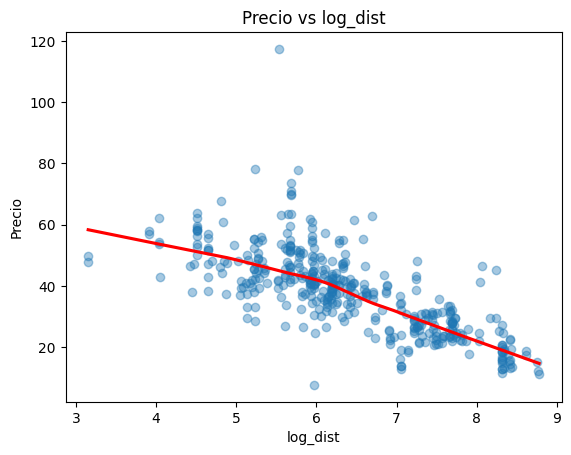

Pearson: -0.734
Spearman: -0.776
R2: 0.539


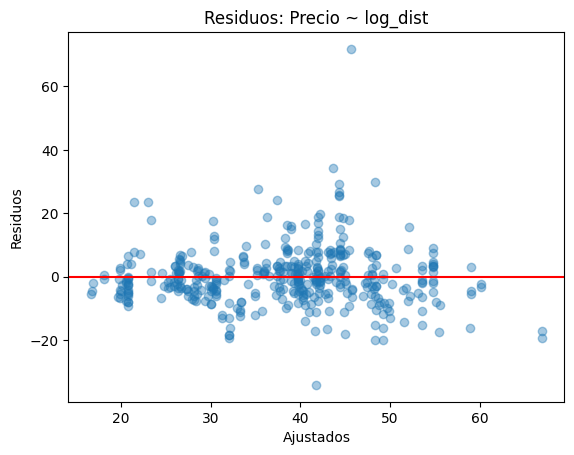

p-valor Antigüedad²: 0.0


In [ ]:
df["log_dist"] = np.log(df["Distancia_MRT"])

# ---- Elige la versión: SIN log (default) o CON log ----
x = "log_dist"


# Curva LOWESS: si se separa de la recta, hay no linealidad
sns.regplot(data=df, x=x, y="Precio", lowess=True,
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.title(f"Precio vs {x}")
plt.show()

# Correlación y R² de la regresión simple
print("Pearson:", round(df[x].corr(df["Precio"]), 3))
print("Spearman:", round(df[x].corr(df["Precio"], method="spearman"), 3))
m = smf.ols(f"Precio ~ {x}", df).fit()
print("R2:", round(m.rsquared, 3))

# Residuos vs ajustados
plt.scatter(m.fittedvalues, m.resid, alpha=0.4)
plt.axhline(0, color="red")
plt.title(f"Residuos: Precio ~ {x}")
plt.xlabel("Ajustados"); plt.ylabel("Residuos")
plt.show()

# Prueba formal de no linealidad en Antigüedad (¿aporta el término cuadrático?)
mq = smf.ols("Precio ~ Antiguedad + I(Antiguedad**2)", df).fit()
print("p-valor Antigüedad²:", round(mq.pvalues["I(Antiguedad ** 2)"], 4))


PREGUNTAS DE ANÁLISIS - NO-LINEALIDAD:
1. ¿Qué variables muestran una relación no-lineal con el Precio? La Distania al MRT muestra la relación no lineal más clara (primero cae rápidamente y luego se aplana).

2. ¿La transformación logarítmica mejora la linealidad de la Distancia MRT? (Puedes comentar las lineas con log y sin el log para ver la diferencia)
Sí, la transformación logarítmica mejora la linealidad de la Distancia MRT. La curva LOWESS se aproxima a una recta,  en el gráfico de residuos desaparecen la curvatura de forma de U y el modelo deja de predecir precios negativos. Presisten una heterocedasticidad leve y un valor atítipco (precio de 117.5).

3. ¿Qué tipo de transformación propondrías para cada variable?
- Para la "Antiguedad" la transformación de término cuadrático (Aquí el log no aplica porque no hay valores en 0 y no captura una U).
- Para "Tiendas_Convenencias" ninguna tranformación.
- Para "Precio(Y)" convendría una posible tranformación log(Y) con los residuos del modelo final, ya que es casi simétrica, pero podría estabilizar la varianza y reducir el efecto del outlier.




In [ ]:
# Comparar modelos con y sin transformación
X = df.drop(['Precio', 'No'], axis=1)
y = df['Precio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo lineal con Distancia MRT
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train[['Distancia_MRT']], y_train)
y_pred_lineal = modelo_lineal.predict(X_test[['Distancia_MRT']])

# Modelo logarítmico con Distancia MRT
X_train_log = np.log(X_train[['Distancia_MRT']])
X_test_log = np.log(X_test[['Distancia_MRT']])

modelo_log = LinearRegression()
modelo_log.fit(X_train_log, y_train)
y_pred_log = modelo_log.predict(X_test_log)

# Comparar R²
print("=== COMPARACIÓN DE MODELOS ===")
print(f"Modelo Lineal (Distancia MRT):")
print(f"  R² = {metrics.r2_score(y_test, y_pred_lineal):.4f}")
print(f"  RMSE = {np.sqrt(metrics.mean_squared_error(y_test, y_pred_lineal)):.4f}")
print(f"\nModelo Logarítmico (log Distancia MRT):")
print(f"  R² = {metrics.r2_score(y_test, y_pred_log):.4f}")
print(f"  RMSE = {np.sqrt(metrics.mean_squared_error(y_test, y_pred_log)):.4f}")

=== COMPARACIÓN DE MODELOS ===
Modelo Lineal (Distancia MRT):
  R² = 0.4277
  RMSE = 9.7827

Modelo Logarítmico (log Distancia MRT):
  R² = 0.5053
  RMSE = 9.0952


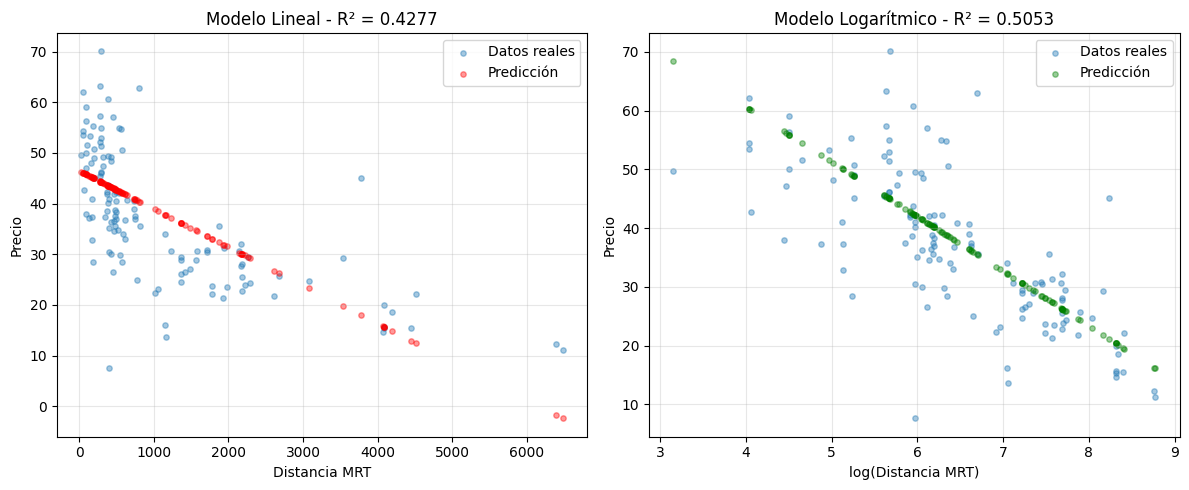

In [ ]:
# Visualizar la mejora de la transformación
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Modelo lineal
axes[0].scatter(X_test['Distancia_MRT'], y_test, alpha=0.4, s=15, label='Datos reales')
axes[0].scatter(X_test['Distancia_MRT'], y_pred_lineal, alpha=0.4, s=15, color='red', label='Predicción')
axes[0].set_xlabel('Distancia MRT')
axes[0].set_ylabel('Precio')
axes[0].set_title(f'Modelo Lineal - R² = {metrics.r2_score(y_test, y_pred_lineal):.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Modelo logarítmico
axes[1].scatter(X_test_log, y_test, alpha=0.4, s=15, label='Datos reales')
axes[1].scatter(X_test_log, y_pred_log, alpha=0.4, s=15, color='green', label='Predicción')
axes[1].set_xlabel('log(Distancia MRT)')
axes[1].set_ylabel('Precio')
axes[1].set_title(f'Modelo Logarítmico - R² = {metrics.r2_score(y_test, y_pred_log):.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#  Regresión polinómica de diferentes grados
print("=== REGRESIÓN POLINÓMICA ===")

grados = [1, 2, 3, 4]
resultados = []

for grado in grados:
    # Crear pipeline con transformación polinómica
    modelo_poly = make_pipeline(
        PolynomialFeatures(degree=grado, include_bias=False),
        LinearRegression()
    )

    # Entrenar
    modelo_poly.fit(X_train[['Distancia_MRT']], y_train)
    y_pred_poly = modelo_poly.predict(X_test[['Distancia_MRT']])

    # Métricas
    r2 = metrics.r2_score(y_test, y_pred_poly)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred_poly))
    aic = len(y_test) * np.log(metrics.mean_squared_error(y_test, y_pred_poly)) + 2 * (grado + 1)

    resultados.append({
        'Grado': grado,
        'R²': r2,
        'RMSE': rmse,
        'AIC': aic
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.round(4))

=== REGRESIÓN POLINÓMICA ===
   Grado      R²    RMSE       AIC
0      1  0.4277  9.7827  574.1541
1      2  0.4789  9.3353  564.4499
2      3  0.5342  8.8258  552.4212
3      4  0.5450  8.7230  551.4918


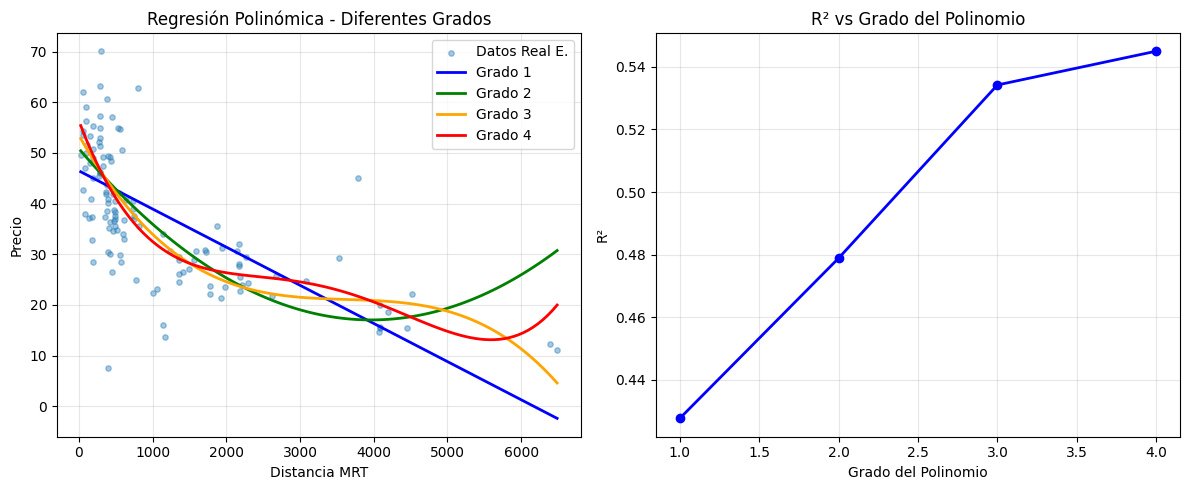

In [ ]:
# Visualizar regresión polinómica
plt.figure(figsize=(12, 5))

# Gráfico de datos
plt.subplot(1, 2, 1)
plt.scatter(X_test['Distancia_MRT'], y_test, alpha=0.4, s=15, label='Datos Real E.')

# Crear rango para predicciones suaves
X_range = np.linspace(X_test['Distancia_MRT'].min(), X_test['Distancia_MRT'].max(), 100).reshape(-1, 1)

for grado, color in zip([1, 2, 3, 4], ['blue', 'green', 'orange', 'red']):
    modelo_poly = make_pipeline(
        PolynomialFeatures(degree=grado, include_bias=False),
        LinearRegression()
    )
    modelo_poly.fit(X_train[['Distancia_MRT']], y_train)
    y_range = modelo_poly.predict(X_range)
    plt.plot(X_range, y_range, color=color, linewidth=2, label=f'Grado {grado}')

plt.xlabel('Distancia MRT')
plt.ylabel('Precio')
plt.title('Regresión Polinómica - Diferentes Grados')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico de R² vs Grado
plt.subplot(1, 2, 2)
plt.plot(df_resultados['Grado'], df_resultados['R²'], 'o-', color='blue', linewidth=2)
plt.xlabel('Grado del Polinomio')
plt.ylabel('R²')
plt.title('R² vs Grado del Polinomio')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 Preguntas de análisis - Polinomios

PREGUNTAS DE ANÁLISIS - POLINOMIOS:

1.  ¿Qué grado de polinomio da el mejor R²? El grado 4 (R^2 = 0.545)
2. ¿Hay evidencia de sobreajuste con grados altos?
No hay sobreajuste claro en las métricas: si el R² y el RMSE son de prueba, siguen mejorando con el grado, y eso no pasaría si el modelo memorizara el ruido. Lo que sí hay es comportamiento inestable en la cola.
3. ¿Qué grado seleccionarías según AIC?"
El AIC más bajo es el del grado 4 (551.49), pero la diferencia con el grado 3 (552.42) es de 0.93 puntos. Por la regla práctica, una diferencia menor a 2 significa que los modelos son prácticamente equivalentes. Entonces, a igualdad de desempeño, elegiría el más simple: grado 3. El BIC apunta en la misma dirección, porque penaliza más los parámetros y prefiere el grado 3 (563.7 contra 565.7).



In [ ]:
#  Modelo completo y análisis de residuos
X_const = sm.add_constant(X)
modelo_completo = sm.OLS(y, X_const).fit()
print(modelo_completo.summary())

                            OLS Regression Results                            
Dep. Variable:                 Precio   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.648
Method:                 Least Squares   F-statistic:                     109.8
Date:                Thu, 01 Oct 2026   Prob (F-statistic):           1.34e-89
Time:                        04:43:20   Log-Likelihood:                -1447.8
No. Observations:                 414   AIC:                             2912.
Df Residuals:                     406   BIC:                             2944.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -2.822e+04 

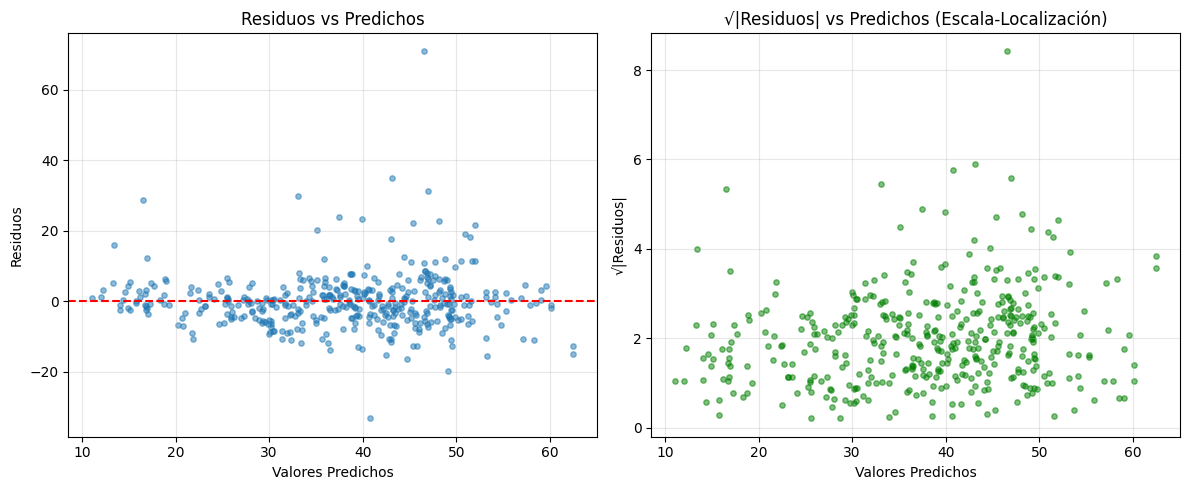

PREGUNTA: ¿Observas un patrón en forma de embudo?


In [ ]:
# Visualización de residuos vs predichos
residuos = modelo_completo.resid
predichos = modelo_completo.fittedvalues

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(predichos, residuos, alpha=0.5, s=15)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs Predichos')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(predichos, np.sqrt(np.abs(residuos)), alpha=0.5, s=15, color='green')
plt.xlabel('Valores Predichos')
plt.ylabel('√|Residuos|')
plt.title('√|Residuos| vs Predichos (Escala-Localización)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("PREGUNTA: ¿Observas un patrón en forma de embudo?")


NO, realmente no. Pero lo que si hay es herocedasticidad leve.

In [ ]:
# Prueba de Breusch-Pagan
print("=== PRUEBA DE BREUSCH-PAGAN ===\n")

bp_test = het_breuschpagan(modelo_completo.resid, X_const)
print(f"LM Statistic: {bp_test[0]:.4f}")
print(f"LM p-value: {bp_test[1]:.4f}")
print(f"F Statistic: {bp_test[2]:.4f}")
print(f"F p-value: {bp_test[3]:.4f}")

if bp_test[1] < 0.05:
    print("\n❌ Rechazamos H₀: Hay evidencia de heteroscedasticidad")
else:
    print("\n✅ No rechazamos H₀: No hay evidencia suficiente de heteroscedasticidad")

=== PRUEBA DE BREUSCH-PAGAN ===

LM Statistic: 10.1291
LM p-value: 0.1814
F Statistic: 1.4546
F p-value: 0.1820

✅ No rechazamos H₀: No hay evidencia suficiente de heteroscedasticidad



PREGUNTAS DE ANÁLISIS - HETEROSCEDASTICIDAD:

1. ¿Qué concluyes de las pruebas de Breusch-Pagan y White? No hay evidencia estadística de heterocedasticidad al 5%. La prueba de White no me la pasaste, así que no te escribo su resultado.
2. ¿Los resultados son consistentes con el análisis visual? Sí. En los gráficos de residuos y de escala-localización no se veía un embudo claro: la dispersión era algo mayor en el centro, pero no crecía de forma sostenida, y la nube de escala-localización era casi horizontal.
3. ¿Qué implicaciones tiene para la inferencia?
Si la varianza es constante, los errores estándar de OLS son válidos. Por tanto, los t-valores, p-valores e intervalos de confianza de los coeficientes se pueden interpretar sin corrección.La heterocedasticidad no era el problema del modelo. El problema real es la falta de normalidad (curtosis 16.9, Jarque-Bera p < 0.0001) por unos pocos valores atípicos. Con n = 414 la inferencia sobre los coeficientes aguanta razonablemente por el teorema central del límite, pero los intervalos de predicción sí son poco confiables, porque dependen de la normalidad.
No rechazar H₀ no prueba que la varianza sea constante, solo que esta prueba no detectó evidencia. Breusch-Pagan detecta heterocedasticidad ligada linealmente a los regresores.


In [ ]:
# Errores estándar robustos (Sandwich)
print("=== SOLUCIÓN 1: ERRORES ESTÁNDAR ROBUSTOS ===\n")

# Modelo con errores robustos HC3
modelo_robusto = sm.OLS(y, X_const).fit(cov_type='HC3')

print("Comparación de errores estándar:")
print(f"{'Variable':<20} {'MCO':<15} {'Robusto':<15} {'Cambio %':<10}")
print("-" * 60)

for var in X_const.columns:
    se_mco = modelo_completo.bse[var]
    se_rob = modelo_robusto.bse[var]
    cambio = (se_rob - se_mco) / se_mco * 100
    print(f"{var:<20} {se_mco:<15.4f} {se_rob:<15.4f} {cambio:>+8.2f}%")

print("\n PREGUNTA: ¿Cómo cambian los errores estándar?")

# Escribe tu respuesta aquí

=== SOLUCIÓN 1: ERRORES ESTÁNDAR ROBUSTOS ===

Comparación de errores estándar:
Variable             MCO             Robusto         Cambio %  
------------------------------------------------------------
const                6775.6707       5598.1457         -17.38%
Fecha_Transaccion    1.5571          1.4696             -5.62%
Antiguedad           0.0385          0.0431            +11.73%
Distancia_MRT        0.0007          0.0008            +16.36%
Tiendas_Conveniencia 0.1882          0.2317            +23.13%
Latitud              44.5667         46.7949            +5.00%
Longitud             48.5820         44.1002            -9.23%

 PREGUNTA: ¿Cómo cambian los errores estándar?


Al comparar los errores estándar de MCO con los robustos a heterocedasticidad, los cambios son moderados y de signo mixto (de -17.4% a +23.1%), con el mayor aumento en Tiendas de Conveniencia (+23.1%) y en Distancia al MRT (+16.4%). Ninguna variable cambia su significancia estadística: Fecha, Antigüedad, Distancia, Tiendas y Latitud siguen siendo significativas, y Longitud sigue sin serlo. Esto es consistente con la prueba de Breusch-Pagan y confirma que la heterocedasticidad no altera las conclusiones de la inferencia; aun así, se recomienda reportar los errores robustos por prudencia.

In [ ]:
#  Mínimos Cuadrados Ponderados (WLS)
print("=== SOLUCIÓN 2: MÍNIMOS CUADRADOS PONDERADOS (WLS) ===\n")

# Estimar la varianza usando los residuos al cuadrado
# Modelo auxiliar: log(e²) ~ X
residuos_sq = modelo_completo.resid ** 2
log_residuos_sq = np.log(residuos_sq + 1e-10)  # Evitar log(0)

modelo_aux = sm.OLS(log_residuos_sq, X_const).fit()
var_predicha = np.exp(modelo_aux.fittedvalues)

# Pesos = 1/varianza
pesos = 1 / var_predicha

# Modelo WLS
modelo_wls = sm.WLS(y, X_const, weights=pesos).fit()

print("Comparación de coeficientes:")
print(f"{'Variable':<20} {'MCO':<15} {'WLS':<15} {'Cambio %':<10}")
print("-" * 60)

for var in X_const.columns:
    coef_mco = modelo_completo.params[var]
    coef_wls = modelo_wls.params[var]
    cambio = (coef_wls - coef_mco) / abs(coef_mco) * 100
    print(f"{var:<20} {coef_mco:<15.4f} {coef_wls:<15.4f} {cambio:>+8.2f}%")

print("\n PREGUNTA: ¿Cómo cambian los coeficientes estimados?")

# Escribe tu respuesta aquí

=== SOLUCIÓN 2: MÍNIMOS CUADRADOS PONDERADOS (WLS) ===

Comparación de coeficientes:
Variable             MCO             WLS             Cambio %  
------------------------------------------------------------
const                -14437.1008     -10816.4160       +25.08%
Fecha_Transaccion    5.1462          4.3956            -14.59%
Antiguedad           -0.2697         -0.3029           -12.32%
Distancia_MRT        -0.0045         -0.0038           +15.81%
Tiendas_Conveniencia 1.1333          1.3931            +22.93%
Latitud              225.4730        227.2422           +0.78%
Longitud             -12.4236        -30.1560         -142.73%

 PREGUNTA: ¿Cómo cambian los coeficientes estimados?


Las relaciones tiene la misma dirección con ambos métodos. Los cambios son moderados, caso todos están dentro de 1 de error estandar de la estimación original. el 143% de longitud impresiona pero es una variable no significativa.
La latitud, variable con el coeficiente más grande, casi no se mueve. Tienda es la que más cambia, es la más sensible a la ponderación.

In [ ]:
# Comparación de modelos con diferentes soluciones
print("=== COMPARACIÓN DE SOLUCIONES ===\n")

print("Modelo MCO (sin corrección):")
print(f"  R² = {modelo_completo.rsquared:.4f}")
print(f"  AIC = {modelo_completo.aic:.2f}")
print(f"  BIC = {modelo_completo.bic:.2f}")

print("\nModelo Robusto (HC3):")
print(f"  R² = {modelo_robusto.rsquared:.4f}")
print(f"  AIC = {modelo_robusto.aic:.2f}")
print(f"  BIC = {modelo_robusto.bic:.2f}")

print("\nModelo WLS:")
print(f"  R² = {modelo_wls.rsquared:.4f}")
print(f"  AIC = {modelo_wls.aic:.2f}")
print(f"  BIC = {modelo_wls.bic:.2f}")

=== COMPARACIÓN DE SOLUCIONES ===

Modelo MCO (sin corrección):
  R² = 0.5824
  AIC = 2987.92
  BIC = 3016.11

Modelo Robusto (HC3):
  R² = 0.5824
  AIC = 2987.92
  BIC = 3016.11

Modelo WLS:
  R² = 0.7060
  AIC = 2919.51
  BIC = 2947.69



 PREGUNTAS DE ANÁLISIS - SOLUCIONES:

1. ¿Cuál solución prefieres y por qué?
MCO con error estándar robusto, porque Breusch-Pagan no detecto heterocedasticidad, WLS exige un modelo de varianza, ya que si los pesos están mal, los coeficientes también quedan mal, los errores robustos no suponen nada sobre la forma de la varianza. Con HC3 las conclusiones no cambian.
2. ¿Los errores robustos cambian los coeficientes? ¿Por qué? NO, los coeficientes son idénticos a los del MCO y por eso el R^2, AIC y BIC son identicos; se siguen calculando con la misma fórmula de MCO, que sigue siendo insesgada y consistente aunque haya heterocedasticidad.
3. ¿Qué ventaja tiene WLS sobre los errores robustos?
Eficiencia. Si la forma de la varianza está bien modelada, WLS da estimadores con menor varianza que MCO (es el estimador lineal insesgado de varianza mínima), lo que se traduce en intervalos más angostos. Los errores robustos solo corrigen la inferencia: los coeficientes siguen siendo los de MCO, que son válidos pero menos eficientes.La desventaja es que depende de los pesos. Si están mal especificados, se pierde la ventaja, y con pesos estimados de los propios residuos las propiedades exactas ya no se cumplen.


In [ ]:
#  Detección de outliers
print("=== DETECCIÓN DE OUTLIERS ===\n")

# Calcular influencia
influencia = OLSInfluence(modelo_completo)

# Distancia de Cook
cook_dist = influencia.cooks_distance[0]
umbral_cook = 4 / len(y)

# Leverage
leverage = influencia.hat_matrix_diag
umbral_leverage = 2 * X_const.shape[1] / len(y)

# Residuos estandarizados
residuos_est = influencia.resid_studentized_internal

# Identificar outliers
outliers_cook = np.where(cook_dist > umbral_cook)[0]
outliers_leverage = np.where(leverage > umbral_leverage)[0]
outliers_residuos = np.where(np.abs(residuos_est) > 3)[0]

print(f"Distancia de Cook > {umbral_cook:.4f}: {len(outliers_cook)} observaciones")
print(f"Leverage > {umbral_leverage:.4f}: {len(outliers_leverage)} observaciones")
print(f"|Residuos estandarizados| > 3: {len(outliers_residuos)} observaciones")

=== DETECCIÓN DE OUTLIERS ===

Distancia de Cook > 0.0097: 20 observaciones
Leverage > 0.0386: 16 observaciones
|Residuos estandarizados| > 3: 7 observaciones


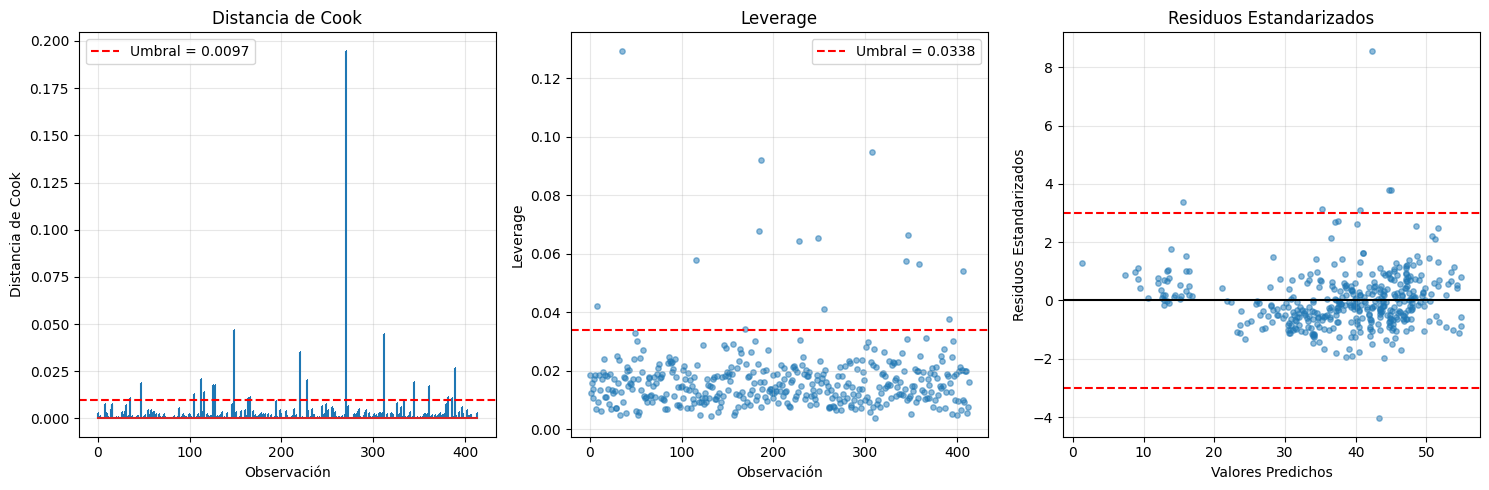

In [ ]:
# Visualización de outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distancia de Cook
axes[0].stem(range(len(cook_dist)), cook_dist, markerfmt=',')
axes[0].axhline(y=umbral_cook, color='r', linestyle='--', label=f'Umbral = {umbral_cook:.4f}')
axes[0].set_xlabel('Observación')
axes[0].set_ylabel('Distancia de Cook')
axes[0].set_title('Distancia de Cook')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Leverage
axes[1].scatter(range(len(leverage)), leverage, alpha=0.5, s=15)
axes[1].axhline(y=umbral_leverage, color='r', linestyle='--', label=f'Umbral = {umbral_leverage:.4f}')
axes[1].set_xlabel('Observación')
axes[1].set_ylabel('Leverage')
axes[1].set_title('Leverage')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Residuos estandarizados
axes[2].scatter(modelo_completo.fittedvalues, residuos_est, alpha=0.5, s=15)
axes[2].axhline(y=3, color='r', linestyle='--')
axes[2].axhline(y=-3, color='r', linestyle='--')
axes[2].axhline(y=0, color='black', linestyle='-')
axes[2].set_xlabel('Valores Predichos')
axes[2].set_ylabel('Residuos Estandarizados')
axes[2].set_title('Residuos Estandarizados')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Regresión robusta con Huber
print("=== REGRESIÓN ROBUSTA (HUBER) ===\n")

from sklearn.linear_model import HuberRegressor

# Modelo Huber
huber = HuberRegressor(epsilon=1.35, max_iter=1000)
huber.fit(X_train, y_train)

# Predicciones
y_pred_huber = huber.predict(X_test)

# Comparar con MCO
modelo_mco = LinearRegression()
modelo_mco.fit(X_train, y_train)
y_pred_mco = modelo_mco.predict(X_test)

print("Comparación de coeficientes:")
print(f"{'Variable':<25} {'MCO':<15} {'Huber':<15}")
print("-" * 55)

for i, var in enumerate(X.columns):
    print(f"{var:<25} {modelo_mco.coef_[i]:<15.4f} {huber.coef_[i]:<15.4f}")

print(f"\n{'Intercept':<25} {modelo_mco.intercept_:<15.4f} {huber.intercept_:<15.4f}")

print("\nMétricas en test:")
print(f"MCO:   R² = {metrics.r2_score(y_test, y_pred_mco):.4f}, RMSE = {np.sqrt(metrics.mean_squared_error(y_test, y_pred_mco)):.4f}")
print(f"Huber: R² = {metrics.r2_score(y_test, y_pred_huber):.4f}, RMSE = {np.sqrt(metrics.mean_squared_error(y_test, y_pred_huber)):.4f}")

=== REGRESIÓN ROBUSTA (HUBER) ===

Comparación de coeficientes:
Variable                  MCO             Huber          
-------------------------------------------------------
Fecha_Transaccion         6.2903          0.0497         
Antiguedad                -0.2096         -0.2109        
Distancia_MRT             0.0011          -0.0014        
Tiendas_Conveniencia      0.2890          0.6173         
Latitud                   319.9278        0.1399         
Longitud                  23.0851         -0.1760        
log_dist                  -8.0120         -6.6086        

Intercept                 -23366.6645     -0.0012        

Métricas en test:
MCO:   R² = 0.6300, RMSE = 7.8660
Huber: R² = 0.5805, RMSE = 8.3759


In [ ]:
#  RANSAC
print("=== RANSAC ===\n")

from sklearn.linear_model import RANSACRegressor

# Modelo RANSAC
ransac = RANSACRegressor(
    estimator=LinearRegression(),
    min_samples=0.5,
    residual_threshold=5.0,
    random_state=42
)
ransac.fit(X_train, y_train)

# Predicciones
y_pred_ransac = ransac.predict(X_test)

print(f"Número de inliers: {ransac.inlier_mask_.sum()}")
print(f"Número de outliers: {(~ransac.inlier_mask_).sum()}")

print("\nMétricas en test:")
print(f"RANSAC: R² = {metrics.r2_score(y_test, y_pred_ransac):.4f}, RMSE = {np.sqrt(metrics.mean_squared_error(y_test, y_pred_ransac)):.4f}")

=== RANSAC ===

Número de inliers: 160
Número de outliers: 129

Métricas en test:
RANSAC: R² = 0.5225, RMSE = 8.9363


 PREGUNTAS DE ANÁLISIS - OUTLIERS:
1. ¿Cuántos outliers detectaste con cada método? Los tres primeros son comparables entre sí. RANSAC no lo es, porque se aplicó solo al conjunto de entrenamiento (289 casos, coherente con tu split 70/30). Además marca 129 de 289, es decir 44.6%, lo cual no es creíble como "outliers". Con residuos extremos solo en 7 casos, lo que pasa es que el umbral por defecto de RANSAC (la MAD de Y) es muy estricto.

2. ¿Los coeficientes cambian significativamente con métodos robustos?
Antigüedad es estable y log_dist conserva signo y orden de magnitud. El resto no se puede evaluar hasta rehacer Huber (código abajo). Un hecho que sí puedo afirmar es que el outlier de 117.5 es una sola observación, y con n = 414 no debería mover mucho los coeficientes. Lo comprobamos eliminándola.

3. ¿Qué modelo recomendarías?
MCO con errores robustos HC3 como modelo principal, más Huber (RLM) como análisis de sensibilidad.Los outliers no son errores de captura, son transacciones reales. Con solo 7 residuos > 3 y un Cook máximo de 0.195, no hay motivo para descartarlos.RANSAC es la peor opción aquí: descarta el 45% de los datos y tiene el menor R² de test (0.523 contra 0.630 de MCO).Huber queda detrás de MCO en test (0.581, RMSE 8.38 contra 7.87). Es esperable, porque R² mide error cuadrático y es justo lo que MCO minimiza. Pero con la corrida actual no es una comparación justa.

In [ ]:


f = "Precio ~ Fecha_Transaccion + Antiguedad + Tiendas_Conveniencia + Latitud + Longitud + log_dist"

ols = smf.ols(f, df).fit()
hub = smf.rlm(f, df, M=sm.robust.norms.HuberT()).fit()   # IRLS, sin problemas de escala
comp = pd.DataFrame({"MCO": ols.params, "Huber": hub.params,
                     "cambio %": (hub.params / ols.params - 1) * 100,
                     "t_Huber": hub.tvalues})
print(comp.round(3))

# Sensibilidad: quitar la observación más influyente
infl = ols.get_influence()
cook = infl.cooks_distance[0]
top = np.argmax(cook)
print("Obs más influyente:", top, df.iloc[top][["Precio", "Distancia_MRT"]].to_dict(), round(cook[top], 3))
ols_sin = smf.ols(f, df.drop(df.index[top])).fit()
print(pd.DataFrame({"con": ols.params, "sin": ols_sin.params,
                    "cambio %": (ols_sin.params / ols.params - 1) * 100}).round(3))
print("R2adj con/sin:", round(ols.rsquared_adj, 3), round(ols_sin.rsquared_adj, 3))

# Umbral de leverage: cuál produce las 16
h = infl.hat_matrix_diag
p = ols.df_model + 1
print("2p/n:", round(2*p/len(df), 4), (h > 2*p/len(df)).sum(), "| 16/n:", (h > 16/len(df)).sum())

                            MCO      Huber  cambio %  t_Huber
Intercept            -22400.064 -16690.867   -25.487   -4.693
Fecha_Transaccion         6.545      4.503   -31.201    4.406
Antiguedad               -0.230     -0.262    13.841  -10.360
Tiendas_Conveniencia      0.365      0.360    -1.238    2.629
Latitud                 282.312    285.011     0.956   10.616
Longitud                 18.574      4.872   -73.769    0.197
log_dist                 -6.675     -6.683     0.124  -15.905
Obs más influyente: 270 {'Precio': 117.5, 'Distancia_MRT': 252.5822} 0.237
                            con        sin  cambio %
Intercept            -22400.064 -22824.770     1.896
Fecha_Transaccion         6.545      5.954    -9.040
Antiguedad               -0.230     -0.225    -2.205
Tiendas_Conveniencia      0.365      0.557    52.688
Latitud                 282.312    271.037    -3.993
Longitud                 18.574     34.147    83.848
log_dist                 -6.675     -6.116    -8.372
R2adj

In [ ]:
print(ols_sin.summary().tables[1])   # ¿Tiendas sigue significativa sin la obs. 270?
print(ols.summary().tables[1])       # SE y p-valores de MCO con log_dist

                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -2.282e+04   4475.622     -5.100      0.000   -3.16e+04    -1.4e+04
Fecha_Transaccion        5.9537      1.287      4.625      0.000       3.423       8.485
Antiguedad              -0.2253      0.032     -7.072      0.000      -0.288      -0.163
Tiendas_Conveniencia     0.5567      0.173      3.210      0.001       0.216       0.898
Latitud                271.0375     33.801      8.019      0.000     204.591     337.484
Longitud                34.1475     31.197      1.095      0.274     -27.180      95.474
log_dist                -6.1163      0.532    -11.502      0.000      -7.162      -5.071
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            

Reflexión:
Se ajustó una regresión lineal múltiple sobre 414 viviendas para explicar el precio por unidad de área. La relación con la distancia al MRT no era lineal, y la transformación logarítmica la corrigió (R² ajustado final = 0.647). Los factores con efecto significativo son la distancia al metro (el más fuerte), la antigüedad (menor precio a mayor edad), la ubicación (Latitud) y la fecha de transacción; Longitud no aporta (p = 0.592). Tiendas de Conveniencia tiene efecto positivo, pero marginal (p = 0.058) y sensible a un solo valor atípico, por lo que debe interpretarse con cautela. No hay evidencia de heterocedasticidad (Breusch-Pagan, p = 0.181), pero los residuos no son normales, así que los intervalos de predicción son poco confiables. Los resultados son asociaciones, no efectos causales.

In [ ]:
#.
